                            PROJEKTNI RAD: Kreiranje i poređenje modela za klasifikaciju teksta
Tema i predmet rada: U ovom radu se bavim analizom i poređenjem različitih načina na koje računar može da razume tekst i svrsta ga u određenu kategoriju. Konkretno, testiram nekoliko modela mašinskog učenja kako bih video koji najbolje prepoznaje sentiment (emociju) u objavama navijača na Twitter-u.

Svrha rada: Glavni cilj mi je da proverim da li se isplati koristiti komplikovane i spore algoritme (poput XGBoost-a) ili su za kratke poruke, kao što su tvitovi, dovoljni i jednostavniji modeli (poput Naive Bayes-a). Želim da pronađem model koji je najprecizniji, a da pritom nije previše složen bez potrebe.

Izvor podataka: Podatke sam preuzeo sa Kaggle platforme. U pitanju je dataset "FIFA World Cup 2022 Tweets" koji sadrži preko 22.000 tvitova objavljenih na dan početka Svetskog prvenstva.
Link ka datasetu: https://www.kaggle.com/datasets/tirendazacademy/fifa-world-cup-2022-tweets

Metodologija i obrazloženje izbora:
Za rad sam napravio četiri različita modela koristeći Pipeline:

Model 1 (TF-IDF + Naive Bayes):
Za razliku od običnog brojanja, TF-IDF umanjuje značaj rečima koje se prečesto pojavljuju, a ističe one koje nose specifično značenje.
Naive Bayes je algoritam mašinskog učenja za klasifikaciju koji predviđa klasu nekog podatka koristeći verovatnoću. Zasniva se na pretpostavci da su sve karakteristike međusobno nezavisne.
Naive Bayes daje dobre rezultate u mnogim realnim primenama pa tako i u analizi sentimenata.


Model 2 (Word Embeddings + Random Forest):
Word Embeddings:Pristup modelovanju teksta gde se svaka reč predstavlja višedimenzionalnim vektorom koji bi trebalo da enkodira što je moguće više značenja (semantike) reči.Značenje reči je u velikoj meri određeno rečima u “okruženju”, odnosno rečima sa kojima se često zajedno pojavljuje.
Random Forest je veoma efikasan i radi sa stablima, slicna bagging ideji sa poboljšanim umanjenjem varijanse.

Model 3 (Hibridni (kombinovani): TF-IDF + Logistička regresija):
U kombinovanom modelu sam uz tekst dodao i numerički podatak – broj lajkova tvita.
Logistička regresija je supervizovani algoritam mašinskog učenja koji se koristi za klasifikaciju i predviđa verovatnoću da nešto pripada određenoj klasi.

Model 4 (XGBoost):
XGBoost je napredni algoritam mašinskog učenja koji poboljšava tačnost i brzinu u odnosu na klasične modele poput običnih stabala odlučivanja i već korišćenog Random Forest-a.

Evulacione metrike:
Accuracy (Tačnost): Ovo mi je glavna mera jer mi jasno govori u koliko procenata je model pogodio tačan sentiment.
F1-score: Ovu metriku koristim kao dodatnu proveru. Pošto u podacima imam mnogo manje negativnih tvitova nego ostalih, F1-score mi pomaže da budem siguran da model nije samo "naučio napamet" najčešće klase, već da stvarno prepoznaje i one ređe kategorije

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import re

from scipy.stats import multinomial
# Alati za modelovanje
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('fifa_world_cup_2022_tweets.csv', index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22524 entries, 0 to 22523
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Date Created     22524 non-null  object
 1   Number of Likes  22524 non-null  int64 
 2   Source of Tweet  22524 non-null  object
 3   Tweet            22524 non-null  object
 4   Sentiment        22524 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.0+ MB


In [3]:
df.head(5)

,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral
1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive
3,2022-11-20 23:58:33+00:00,1,Twitter Web App,Golden Maknae shinning bright\n\nhttps://t.co/...,positive
4,2022-11-20 23:58:28+00:00,0,Twitter for Android,"If the BBC cares so much about human rights, h...",negative


In [4]:
# posto nasi ucitani podaci, sadrze tagove (@naziv_twiter_profila), nas model bi potencijalno mogao lose da nauci (tkz. overfiting) jer ukoliko bi na primer video u 10 redova @CanadaSoccerEN, zakljucio bi na primer da je vrednost varijable 'Sentiment' za te redove najcesce positive, a to ne mora da znaci da je uopsteno u celom datasetu tako
#Zbog toga, u fazi preprocesiranja su konkretna korisnička imena (mentions) zamenjena su oznakom @user, dok su URL linkovi zamenjeni oznakom http.

#definisemo funkciju koja ce sve tagove da pretvori u jedan isti '@user'; takodje cemo i sve linkove pretvoriti u samo 'http'
def twitter_preprocess(text):
    text = str(text).lower()
    # Menjamo @bilo_sta u @user, uz pomoc regexa
    text = re.sub(r'@[A-Za-z0-9_]+', '@user', text)
    # Menjamo sve linkove u 'http'
    text = re.sub(r'http\S+', 'http', text)
    # Uklanjamo specijalne karaktere radi predustroznosti
    text = re.sub(r'[^a-zA-Z\s@]', '', text)
    text = text.replace('\n', ' ')
    return text

df['Clean_Tweet'] = df['Tweet'].apply(twitter_preprocess)

# Provera da li su tagovi sada @user i da li kod linkova pise samo 'hhtp'
display(df[['Tweet', 'Clean_Tweet']].head(10))

,Tweet,Clean_Tweet
0,What are we drinking today @TucanTribe \n@MadB...,what are we drinking today @user @user @user...
1,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,amazing @user worldcup launch video shows how...
2,Worth reading while watching #WorldCup2022 htt...,worth reading while watching worldcup http
3,Golden Maknae shinning bright\n\nhttps://t.co/...,golden maknae shinning bright http jeonjungko...
4,"If the BBC cares so much about human rights, h...",if the bbc cares so much about human rights ho...
5,"And like, will the mexican fans be able to scr...",and like will the mexican fans be able to scre...
6,Look like a only me and the Jamaican football ...,look like a only me and the jamaican football ...
7,Really? Football on a Monday morning at 9 and ...,really football on a monday morning at and a...
8,"As the World Cup starts in Qatar, it’s Black A...",as the world cup starts in qatar its black awa...
9,#WorldCup2022 @ITVSport &amp; @LFSYSTEMMUSIC g...,worldcup @user amp @user go together so well h...


In [5]:
# 1. Menjamo originalnu kolonu Tweet našom očišćenom verzijom
df['Tweet'] = df['Clean_Tweet']

# 2. Brišemo pomoćnu kolonu Clean_Tweet jer nam više ne treba
df.drop(columns=['Clean_Tweet'], inplace=True)

df.head(5)

,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,2022-11-20 23:59:21+00:00,4,Twitter Web App,what are we drinking today @user @user @user...,neutral
1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,amazing @user worldcup launch video shows how...,positive
2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,worth reading while watching worldcup http,positive
3,2022-11-20 23:58:33+00:00,1,Twitter Web App,golden maknae shinning bright http jeonjungko...,positive
4,2022-11-20 23:58:28+00:00,0,Twitter for Android,if the bbc cares so much about human rights ho...,negative


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22524 entries, 0 to 22523
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Date Created     22524 non-null  object
 1   Number of Likes  22524 non-null  int64 
 2   Source of Tweet  22524 non-null  object
 3   Tweet            22524 non-null  object
 4   Sentiment        22524 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.0+ MB


In [7]:
# 2. Ispitivanje vrednosti ciljne varijable 'Sentiment'
print("Broj tvitova po kategoriji sentimenta:")
sentiment_dist = df['Sentiment'].value_counts()
print(sentiment_dist)

Broj tvitova po kategoriji sentimenta:
Sentiment
positive    8489
neutral     8251
negative    5784
Name: count, dtype: int64


In [8]:
#provera balansa klasa u procentima
print("Proporcije varijable 'sentiment' u datasetu:")
round(df['Sentiment'].value_counts(normalize=True)*100,2)

Proporcije varijable 'sentiment' u datasetu:


Sentiment
positive    37.69
neutral     36.63
negative    25.68
Name: proportion, dtype: float64

In [9]:
#Analizom ciljne varijable Sentiment vidimo da dataset sadrži tri klase (positive, negative, neutral)
#Kao što vidimo po broju pojavljivanja sve 3 vrednosti, vrednost "negative" se znacajno manje puta pojavljuje nego "positive" i "neutral"

In [10]:
#jos jednom cemo kroz 5 nasumicnih redova proveriti da li je tesktualni podatak 'tweet' ociscen kako treba
print("\nPrimeri ociscenih tvitova iz dataseta:")
for i, tweet in enumerate(df.sample(n=5, random_state=42)['Tweet']):
    print(f"{i+1}. {tweet}\n")


Primeri ociscenih tvitova iz dataseta:
1. ecuador players after losing  against qatar tonight fifaworldcup worldcupqatar worldcup http

2. morgan freeman too old damn cant believe worldcup

3. so i guess we have a worldcup opener ahead as governing bodies the fia and fifa are pretty similar  and the cup is tainted from way before its begin this will be my first and also my last one about the event

4. so are we going to hear @user and other pundits in  talk about the usa regarding their war crimes and controversies   qatar qatar worldcup worldcup

5. should have had a hattrick already qatecu worldcup



In [11]:
#jos jedna bitna stvar za analizu naseg teksta (tvitova) je da ustanovimo njihovu duzinu, jer to moze uticati na analizu sentimenta tvita- u praksi "ishitrene, negativne" reakcije su kraće družine tvitovi, dok kad smo zadovoljni (positive) to su uglavnom malo duži tvitovi sa pohvalama
# Kreiranje nove kolone sa dužinom svakog tvita
df['tweet_len'] = df['Tweet'].apply(len)

# Prikazacemo osnovne statistike za dužinu tvitova (parametri deskriptivne statistike) kao sto su std - standardna devijacija, min - minimalna duzina tvita, max - maximalna duzina tvita...
print(df['tweet_len'].describe())

count    22524.000000
mean       110.236814
std         67.108564
min         13.000000
25%         56.000000
50%         93.000000
75%        155.000000
max        308.000000
Name: tweet_len, dtype: float64


In [12]:
# posto je na drustvenoj mrezi twiter dozvoljeno maximalno 280 karaktera po jednom tvitu a kao sto vidimo iz statistike nasa max vrednost je 308, sto ukazuje na moguce previse nepotrebnih tagova (@user) ili dodatnih html entiteta (gde se u kodu umesto sam & pise &amp sto vestacki povecava duzinu karaktera)
# Pronalaženje i ispis najdužeg tvita kao dokaz za analizu
longest_tweet = df[df['tweet_len'] == df['tweet_len'].max()]['Tweet'].iloc[0]
print(f"Najduži tvit ({df['tweet_len'].max()} karaktera):\n")
print(longest_tweet)

Najduži tvit (308 karaktera):

@user @user @user @user @user @user im not sure why watching it is relevant did alan lecture british people on human rights  there are many reasons why holding worldcup in qatar is wrong footballing as well as political  i can watch it amp also believe the decision making behind it was ridiculous or corrupt


In [13]:
#kao sto se vidi, pretpostavka je tacna imamo vise user tagova i na kraju drugog reda amp; ovo potvrđuje da dužina tvita u sirovom obliku nije uvek direktno povezana sa količinom korisnih informacija

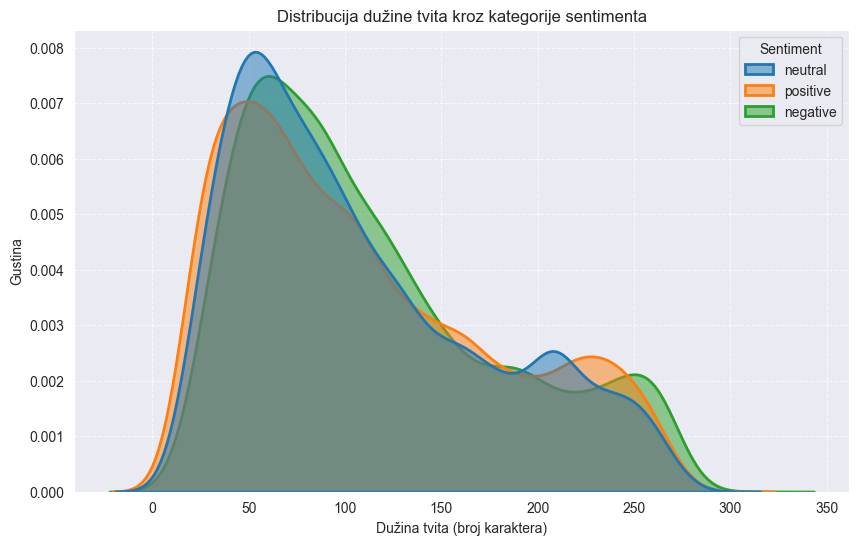

In [14]:
#kreiranje kdeplot-a
plt.figure(figsize=(10, 6))

sb.kdeplot(data=df, x='tweet_len', hue='Sentiment', fill=True, common_norm=False, alpha=0.5, linewidth=2)

plt.title('Distribucija dužine tvita kroz kategorije sentimenta')
plt.xlabel('Dužina tvita (broj karaktera)')
plt.ylabel('Gustina')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [15]:
#Kada pogledamo ovaj grafik, vidimo da su krive za sve tri vrste sentimenta (pozitivan, negativan, neutralan) skoro iste i da se skoro preklapaju. To mi govori da dužina tvita ne zavisi od toga da li je neko srećan ili besan zbog utakmice – navijači pišu slično u oba slučaja. Na primer kad naš model vidi tvit dužine 50, jako teško će na osnovu te inofrmacije znati kojoj klasi sentimenata pripada taj tvit
#Primetio sam da na grafiku postoje dva "brda". Prvo, veće brdo (između 40 i 60 slova), su verovatno oni brzi navijački komentari i uzvici. Drugo, manje brdo (tamo oko 200-250 slova), su verovatno oni duži tvitovi, sa dodatno analizom necega u vezi svetskog prvenstva, sa puno linkova i @user tagova koje smo ranije videli kada smo tražili najduži tvit. Pošto su ove krive toliko slične, jasno je da samo na osnovu dužine ne možemo da znamo kakvog je raspoloženja navijač.



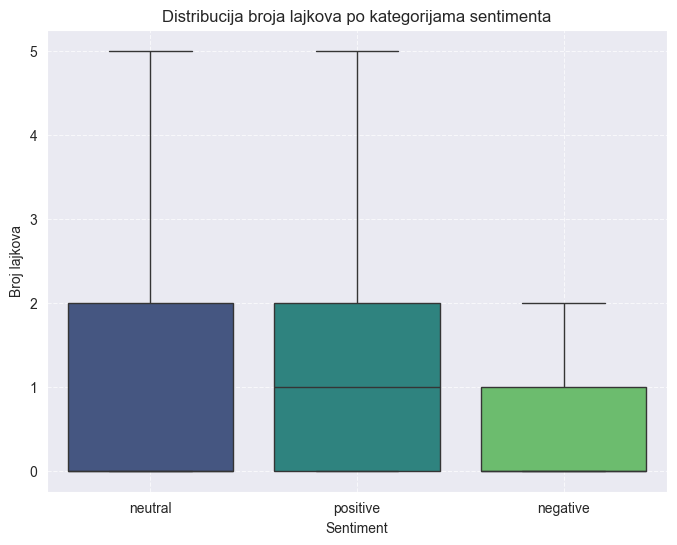

In [16]:
#Sada proveravamo za broj lajkova
# Kreiranje boxplot-a za broj lajkova po kategorijama sentimenta
plt.figure(figsize=(8, 6))

sb.boxplot(data=df, x='Sentiment', y='Number of Likes', hue='Sentiment', palette='viridis',showfliers=False)

plt.title('Distribucija broja lajkova po kategorijama sentimenta')
plt.ylabel('Broj lajkova')
plt.xlabel('Sentiment')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [17]:
#Ono što vidim je da su 'neutralni' i 'pozitivni' tvitovi skoro identični po broju lajkova – ljudi podjednako reaguju na lepe vesti i na obične informacije sa prvenstva. Sa druge strane, 'negativni' tvitovi (zeleni box) imaju nešto niži prosek lajkova. To mi govori da navijači na Twitteru radije podržavaju pozitivne objave nego što lajkuju nečije kritike (negativne komentare). Ovo je zanimljivo jer pokazuje da broj lajkova nekog tvita se može povezati sa tim kakav mu je sentiment

#napomena: izbacio sam prikaz ekstremnih vrednosti (outliera) na grafiku jer postoji mali broj tvitova sa ogromnim brojem lajkova (čak neki i preko 300) koji bi grafički potpuno potisnuli ostale podatke i učinili poređenje nemogućim. Fokusiranjem na podatke slicnih brojeva lajkova, jasno se vidi da neutralni i pozitivni tvitovi imaju veći broj lajkova u poređenju sa negativnim.

#ZAKLJUČAK: Zbog grafičke analize koju smo izvršili, varijablu 'tweet_len' NEĆEMO koristiti kao ulazni podatak za treniranje modela, već ćemo se fokusirati isključivo na sadržaj teksta i broj lajkova.

In [18]:
# Pravimo podskup podataka (novi dataset) sa kolonama koje su nam važne za modele
# Tweet (tekst), tweet_len (dužina) i Number of Likes (popularnost)
df_sub = df[['Tweet', 'Number of Likes', 'Sentiment']].copy()
print("Odabrane kolone za fazu modelovanja:")
display(df_sub.head(10))

Odabrane kolone za fazu modelovanja:


,Tweet,Number of Likes,Sentiment
0,what are we drinking today @user @user @user...,4,neutral
1,amazing @user worldcup launch video shows how...,3,positive
2,worth reading while watching worldcup http,1,positive
3,golden maknae shinning bright http jeonjungko...,1,positive
4,if the bbc cares so much about human rights ho...,0,negative
5,and like will the mexican fans be able to scre...,0,negative
6,look like a only me and the jamaican football ...,0,neutral
7,really football on a monday morning at and a...,0,negative
8,as the world cup starts in qatar its black awa...,1,positive
9,worldcup @user amp @user go together so well h...,0,positive


In [19]:
#Na osnovu prethodne analize, zaključio sam da su za klasifikaciju sentimenta najbitniji sam tekst tvita i broj lajkova, jer oni mogu biti korisni dodatni faktori u kompleksnijim modelima. Zato sam napravio novi DataFrame pod nazivom df_sub koji sadrži samo ove tri kolone. Ostale podatke, kao što su izvor tvita ili tačan datum objave, izbacio sam jer ne doprinose samom prepoznavanju emocija u tekstu, a samo bi usporili rad modela

In [20]:
#sada ćemo da za neki tvit iz našeg dataseta da izvučemo za svaku reč njen koren kako bismo prikazali kako radi spacy
import spacy
# Učitavamo 'md' model jer on sadrži prave vektore (300 dimenzija, 20k jedinstvenih vektora)
# Izvor: https://spacy.io/models/en#en_core_web_md
nlp = spacy.load('en_core_web_md')

sample_tweet = df_sub['Tweet'].iloc[0]
doc = nlp(sample_tweet)

print(f"Originalni tekst tvita:\n{sample_tweet}\n")

print(f"{'Reč ':<15} | {'Koren reči ':<15}")
print("-" * 35)

for token in doc:
    if not token.is_space:
        if token.text in ['@user', 'http']:
            lemma_val = token.text
        else:
            lemma_val = token.lemma_

        print(f"{token.text:<15} | {lemma_val:<15}")

Originalni tekst tvita:
what are we drinking today @user  @user  @user  @user   worldcup http

Reč             | Koren reči     
-----------------------------------
what            | what           
are             | be             
we              | we             
drinking        | drink          
today           | today          
@user           | @user          
@user           | @user          
@user           | @user          
@user           | @user          
worldcup        | worldcup       
http            | http           


In [21]:
#Proverio sam kako spaCy obrađuje jedan nasumičan tvit i rezultati su baš onakvi kakve sam želeo da vidim. Program je uspešno rastavio rečenicu na delove i svaku reč vratio na njen osnovni oblik.

#Najbolji primer je reč 'drinking' koju je prepoznao kao 'drink', ili 'are' koju vidi kao glagol 'be'. Ovo mi je super bitno za kasnije modele (Model 2 i 3), jer ne želim da računar reči 'pije', 'piju' ili 'pio' gleda kao tri različite stvari, već kao jednu istu radnju. Time pojednostavljujem podatke i pomažem modelu da bolje uči

In [22]:
from spacy import displacy

# 1. Tabela sa detaljima (vrste reči i koren)
token_data = [
    {'Tekst': token.text, 'Vrsta reči': token.pos_, 'Koren': token.lemma_}
    for token in doc if not token.is_space
]
df_tokens = pd.DataFrame(token_data)
display(df_tokens)

# 2. Grafički prikaz kako su reči povezane u rečenici
displacy.render(doc, style='dep', jupyter=True, options={'compact': True})

,Tekst,Vrsta reči,Koren
0,what,PRON,what
1,are,AUX,be
2,we,PRON,we
3,drinking,VERB,drink
4,today,NOUN,today
5,@user,PROPN,@user
6,@user,ADJ,@us
7,@user,NOUN,@user
8,@user,PROPN,@user
9,worldcup,NOUN,worldcup


In [23]:
#Nakon što sam izvukao sve reči, napravio sam detaljan tabelarni i grafički prikaz strukture tvita. Tabela mi je otkrila da spacy veoma precizno prepoznaje kojoj vrsti reči pripada svaka reč, što je jako važno za dobru analizu (na primer sada model zna da pomoćni glagol are (od glagola to be) utiče samo na 'građenje' glagola drink, a da nema nikakvo dublje značenje za našu analizu).

#Grafikon zavisnosti mi je pokazao kako je rečenica zapravo konstruisana oko glagola 'drinking'. Na primer, vidim direktnu vezu između subjekta 'we' i radnje (nsubj - ko vrši radnju, subjekat u rečenici), kao i to kako reči poput 'today' bliže određuju taj glagol (znamo tačno kada se pilo). Ovakva duboka analiza omogućava modelu da u kasnijim fazama ne posmatra reči samo kao skup slova, već da 'razume' ko šta radi u rečenici, što drastično popravlja preciznost i daje bolje rezultate analize sentimenta.

In [24]:
# Definisanje funkcije za ciscenje
def spacy_preprocessing(text):
    doc = nlp(text)
    cleaned_tokens = []

    for token in doc:
        if token.text.lower() in ['@user', 'http']:
            continue
        if token.is_stop or token.is_punct or token.like_num:
            continue
        cleaned_tokens.append(token.lemma_.lower().strip())
    return " ".join(cleaned_tokens)

#primenjujemo definisanu funkciju kako bismo dobili ocisceni tvit
df_sub['Clean_Tweet_Final'] = df_sub['Tweet'].apply(spacy_preprocessing)
display(df_sub[['Tweet', 'Clean_Tweet_Final']].head())

,Tweet,Clean_Tweet_Final
0,what are we drinking today @user @user @user...,drink today worldcup
1,amazing @user worldcup launch video shows how...,amazing worldcup launch video show face canad...
2,worth reading while watching worldcup http,worth read watch worldcup
3,golden maknae shinning bright http jeonjungko...,golden maknae shin bright jeonjungkook jungko...
4,if the bbc cares so much about human rights ho...,bbc care human right homosexual right woman ri...


In [25]:
#Reč "http" sama po sebi ne nosi emociju.. Bilo da je tvit pozitivan ("Obožavam fudbal! http...") ili negativan ("Sudija je užasan! http..."), oznaka linka je ista, a i pojavljuje se u svim klasama sentimenata podjednako, jer je to samo obican link.. Model bi mogao pogrešno da nauči da je "http" bitan faktor, što naravno nije slučaj, iz tog razloga je izbačen

#iz slicnog razloga smo izbacili i tag @user, jer tagovi na nekom tvitu ni na koji nacin ne utiču na emociju u tvitu, pa smo zbog toga i to izbacili

#Kao što se vidi u koloni Clean_Tweet_Final, proces preprocesiranja je uspešno izvršen.
# Ovakvim čišćenjem smo drastično smanjili broj reči koje model mora da nauči, a i svođenjem reči na osnovni oblik  model će sada sve gramatičke varijacije iste reči posmatrati kao jedan pojam

In [26]:
from sklearn.preprocessing import LabelEncoder

#Potencijalno u nasem ogromnom datasetu od preko 22000 tvitova postoje duplikati.
# Na društvenim mrežama kao što je Twitter, često se dešava da ljudi kopiraju isti tekst (retweet) ili da botovi pišu isto. Ako ne obrišemo duplikate, naš model može da "nabuba" te rečenice i da nam da lažnu sliku o tome koliko je zapravo precizan.
#Zbog toga brisemo duplikate

# 1. Provera i brisanje duplikata
print(f"Broj redova pre brisanja duplikata: {len(df_sub)}")
df_sub = df_sub.drop_duplicates(subset=['Clean_Tweet_Final'])
print(f"Broj redova nakon brisanja: {len(df_sub)}")

# 2. Pretvaranje Sentiment-a u brojeve (Label Encoding)
# neutral -> 1, positive -> 2, negative -> 0
le = LabelEncoder()
df_sub['Sentiment_Num'] = le.fit_transform(df_sub['Sentiment'])


mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\nMapiranje sentimenta: {mapping}")

# 3. Podela podataka na X i y
X = df_sub['Clean_Tweet_Final']
y = df_sub['Sentiment_Num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nPodaci su spremni! Trening set: {len(X_train)}, Test set: {len(X_test)}")


Broj redova pre brisanja duplikata: 22524
Broj redova nakon brisanja: 21082

Mapiranje sentimenta: {'negative': 0, 'neutral': 1, 'positive': 2}

Podaci su spremni! Trening set: 16865, Test set: 4217


In [27]:
#Kao što se vidi iz rezultata, broj redova se smanjio sa 22 524 na 21 082, što znači da je bio popriličan broj duplikata.
#Takođe, izvršio sam Label Encoding sentimenta
# Na kraju, podatke sam podelio tako da mi je za učenje ostalo 16.865 tvitova, dok ću na preostalih 4 217 testirati koliko je model zapravo naučio

In [28]:
#sada kada su podaci potpuno sređeni i model istreniran, prelazimo na na naš algoritam za model1
#U modelu1 koristimo već pomenut algoritam Naive Bayes. Cilj nam je da uz pomoć TF-IDF-a , izracunamo im tf-idf vrednosti  (koliko se često neka reč pojavljuje u nekom konkretnom tvitu(tf(d,f)) * koliko se retko reč pojavljuje u celom datasetu (idf(t,D))i da onda uz pomoc Naive Bayesa koji koristi te vrednosti i ono što je naučio iz modela, uz pomoć bajesove fomule izračunamo ukupnu verovatnoću da tvit pripada određenoj klasi (pozitivnoj, negativnoj ili neutralnoj) na osnovu reči koje sadrži (kad analiziramo sve reči iz nekog tvita). -> gde je najveća verovatnoća, tu će model svrstati taj tvit kojoj klasi sentimenata pripada

#Kreiranje Pipeline-a
#prvo vektorizacija (TF-IDF), pa onda klasifikator (Naive Bayes)
pipeline_model1 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

#Treniranje modela
pipeline_model1.fit(X_train, y_train)

#Ispis rezultata
display(pipeline_model1)

,steps,"[('tfidf', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


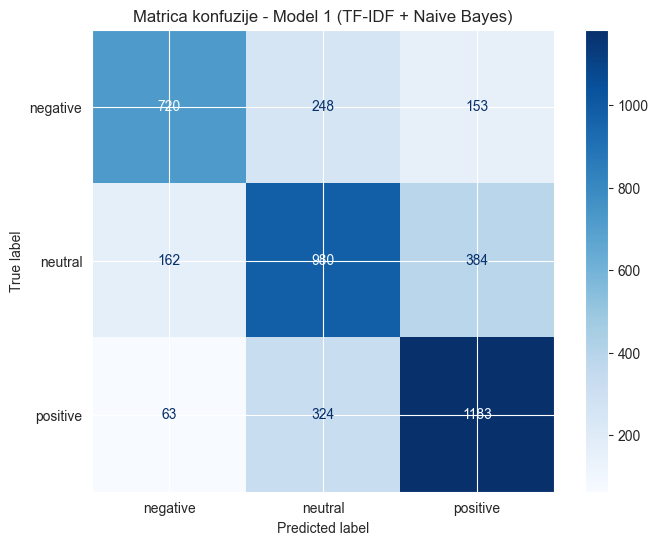

--- MODEL 1: IZVEŠTAJ O KLASIFIKACIJI ---
              precision    recall  f1-score   support

    negative       0.76      0.64      0.70      1121
     neutral       0.63      0.64      0.64      1526
    positive       0.69      0.75      0.72      1570

    accuracy                           0.68      4217
   macro avg       0.69      0.68      0.68      4217
weighted avg       0.69      0.68      0.68      4217



In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

#Tražimo od Pipeline-a da predvidi sentimente za test set
y_pred = pipeline_model1.predict(X_test)

#Crtamo matricu konfuzije
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)
plt.title('Matrica konfuzije - Model 1 (TF-IDF + Naive Bayes)')
plt.show()

# Pravimo tabelu sa rezultatima
print("--- MODEL 1: IZVEŠTAJ O KLASIFIKACIJI ---")
# Koristimo le.classes_ da dobijemo prava imena: negative, neutral, positive
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [30]:
#sad cemo da analiziramo naš model, to jest koliko dobro je on naučio.
#što se tiče matrice konfuzije u njoj su predstavljeni:
#redovi - true labels - stvarni sentiment tvita
#kolone - predicted labels - ono što je model predvideo na osnovu učenja

#konkretno u mom modelu:
#Negative (1121 tvita)
#1)  720 tvitova je model predvideo da su negativni tvitovi što oni i zaista jesu
#2)  248 tvitova je model predvideo da su neutralni tvitovi a oni su zapravo negativni
#3)  153 tvita je model predvideo da su pozitivni tvitovi a oni su zapravo negativni

#Neutral (1526 tvitova)
#1)  980 tvitova je model predvideo da su neutralni tvitovi što oni i zaista jesu
#2)  162 tvita je model predvideo da su negativni tvitovi a oni su zapravo neutralni
#3)  384 tvita je model predvideo da su pozitivni tvitovi a oni su zapravo neutralni

#Positive (1570 tvitova)
#1)  1183 tvitova je model predvideo da su pozitivni tvitovi što oni i zaista jesu
#2)  63 tvita je model predvideo da su negativni tvitovi a oni su zapravo pozitivni
#3)  324 tvita je model predvideo da su neutralni tvitovi a oni su zapravo pozitivni

#što se tiče parametara koji su indikatori koliko je naš model dobro naučio:
#precision - pokazuje koliko smo tvitova predvideli tačno u odnosu na ukupnu predikciju za konkretan sentiment: tačni pozitivni / svi predviđeni kao ta klasa
#1) positive - 0.69  Od svih tvitova koje je model označio kao pozitivne,69% je zaista bilo pozitivno
#2) negative - 0.76  Od svih tvitova koje je model označio kao negativne,76% je zaista bilo negativno
#3) neutral -  0.63  Od svih tvitova koje je model označio kao neutralne,63% je zaista bilo neutralno

#recall - pokazuje koliko smo tvitova predvideli tačno u odnosu na stvaran broj sentimenata iz konkretne klase: tačni pozitivni / svi stvarni iz te klase
#1) positive - 0.75 Od svih stvarno pozitivnih tvitova,model je prepoznao 75%
#2) negative - 0.64 Od svih stvarno negativnih tvitova,model je prepoznao samo 64%
#3) neutral - 0.64 Od svih stvarno neutralnih tvitova,model je prepoznao samo 64%

#f1 score - mera koja balansira precision i recall;  Ako je precision visok a recall nizak → F1 opada. Ako su oba solidna → F1 je dobar
#f1 score je u nasem modelu priblizno 0,69, što znači da nema ekstremnih slabosti, ali nije “jak” model

#accuarcy - pokazuje koliki je procenat tačnih predikcija u celom modelu; kod nas je to 68% što npr. znači da od 10 tvitova, naš model uspešno predvividi za 7 tvitova kojoj klasi sentimenta pripada

#macro average - : Ova mera računa prosek tako što svakoj klasi daje istu težinu, bez obzira na to koliko tvitova ima u njoj. Pošto je ovaj broj visok (0.68) i skoro identičan ukupnoj tačnosti, to nam potvrđuje da model nije 'pristrasan' samo prema većinskim klasama, već da solidno prepoznaje i negativne tvitove kojih ima najmanje u bazi."

#weight avg - Za razliku od Macro proseka, ovaj broj uzima u obzir broj uzoraka u svakoj klasi. Pošto nam je i ovaj prosek 0.68, zaključujemo da je model postigao solidan balans i da su performanse stabilne kroz ceo dataset

#uopšteni zaključak: F1-score pokazuje da je model umerenog kvaliteta, bez ekstremnih grešaka, ali sa prostorom za unapređenje. Neutralna klasa je najproblematičnija (najniži procenat f1 score-a), što je uobičajeno u sentiment analizi, jer neutralni stavovi često sadrže elemente i pozitivnog i negativnog tona

#napomena: u ovom prvom modelu sam detaljno analizirao sve podatke za svaku entimentalnu klasu, kao i sve evulacione metrike kako bih pokazao da mi je jasno šta nam koji broj u matrici konfuzije pokazuje kao i šta nam koja evulaciona metrika u izveštaju govori. Za ostale modele ću dati uopšteniji komentar sa fokusom na najbitnije.

In [52]:
#Nakon što smo dobili prve rezultate i videli da model ima problem sa neutralnom klasom, nećemo se zaustaviti na početnim podešavanjima. Sada uvodimo GridSearchCV kako bismo pronašli najbolje "hiper-parametre" za naš Model 1.

#Cilj nam je da vidimo možemo li kroz ove promene da podignemo onih početnih 68% tačnosti i dobijemo što bolji F1-score, koji nam je najbitniji zbog balansa između klasa. Na kraju ćemo ponoviti testiranje da vidimo koliki je napredak.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.85, 1.0], #izbacujemo reci koje se pojavljuju u vise od 85% tvitova
    'nb__alpha': [0.01, 0.1, 0.5, 1.0]
}
grid_search = GridSearchCV(pipeline_model1, param_grid, cv=5, scoring='f1_weighted', n_jobs= 1)

# 3. Fit radimo nad X_train (tekstom), jer Pipeline sam radi transformaciju
print("Tražim najbolje parametre kroz Pipeline...")
grid_search.fit(X_train, y_train)

# 4. Prikaz najboljih rezultata
print(f"Najbolji parametri: {grid_search.best_params_}")


# 5. Evaluacija najboljeg modela
best_pipeline = grid_search.best_estimator_
y_pred_m1_opt = best_pipeline.predict(X_test)

print("\n --- MODEL 1: OPTIMIZOVANI IZVEŠTAJ ---")
print(classification_report(y_test, y_pred_m1_opt, target_names=le.classes_))

Tražim najbolje parametre kroz Pipeline...
Najbolji parametri: {'nb__alpha': 0.5, 'tfidf__max_df': 1.0, 'tfidf__ngram_range': (1, 1)}

 --- MODEL 1: OPTIMIZOVANI IZVEŠTAJ ---
              precision    recall  f1-score   support

    negative       0.74      0.70      0.72      1121
     neutral       0.64      0.62      0.63      1526
    positive       0.70      0.75      0.72      1570

    accuracy                           0.69      4217
   macro avg       0.69      0.69      0.69      4217
weighted avg       0.69      0.69      0.69      4217



In [32]:
#Rezultati optimizacije hiper-parametara pokazali su da je model poboljšan- ukupna tačnost se povećala sa 68 na 69%.
# Primećujemo bitan napredak u Recall vrednosti za negativnu klasu (skok sa 0.64 na 0.70). Ovo znači da je optimizovana alpha vrednost od 0.5 pomogla modelu da bolje prepozna negativne tvitove, što je bio jedan od ciljeva.

In [33]:
#U drugom modelu prelazimo na semantičko modeliranje pomoću Word Embeddings tehnike. Koristimo spaCy en_core_web_md model koji svaku reč predstavlja kao gusti vektor od 300 dimenzija.
# Za klasifikaciju biramo Random Forest, algoritam koji koristi Bootstrapping za kreiranje različitih stabala odlučivanja. Pri svakom grananju, model nasumično bira podskup od  m ≈ sqrt(p) prediktora.
#Nasumični izbor podskupa prediktora kod RF-a dodatno smanjuje korelisanost rezultata stabla, što vodi većem smanjenju varijanse
import numpy as np

# Funkcija za pretvaranje tvita u vektor putem "Word Averaging" metode.
def get_tweet_vector(text):
    return nlp(text).vector

# Procesiranje trening i test seta
train_docs = list(nlp.pipe(X_train.astype(str), batch_size=100))
X_train_vectors = np.array([doc.vector for doc in train_docs])

test_docs = list(nlp.pipe(X_test.astype(str), batch_size=100))
X_test_vectors = np.array([doc.vector for doc in test_docs])



In [34]:
# Definisanje Pipeline-a za Model 2
# Ovde nemamo 'vectorizer' korak jer smo vektore već izvukli iz spaCy-ja
# Random Forest: model koji koristi 'Bagging' (Bootstrap + Aggregation).
# Pri svakom splitu biramo nasumičan broj prediktora m ≈ sqrt(p); p->svi prediktori.
pipeline_model2 = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_model2.fit(X_train_vectors, y_train)

,steps,"[('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


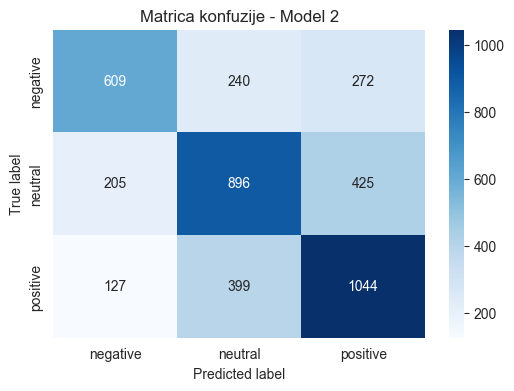

--- MODEL 2: IZVEŠTAJ O KLASIFIKACIJI
              precision    recall  f1-score   support

    negative       0.65      0.54      0.59      1121
     neutral       0.58      0.59      0.59      1526
    positive       0.60      0.66      0.63      1570

    accuracy                           0.60      4217
   macro avg       0.61      0.60      0.60      4217
weighted avg       0.61      0.60      0.60      4217



In [35]:
# Predviđanje na test setu
y_pred_model2 = pipeline_model2.predict(X_test_vectors)

#kreiramo matricu konfuzije
conf_matrix2 = confusion_matrix(y_test, y_pred_model2)

plt.figure(figsize=(6, 4))
sb.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrica konfuzije - Model 2')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# 3. Izveštaj o klasifikaciji
print("--- MODEL 2: IZVEŠTAJ O KLASIFIKACIJI")
print(classification_report(y_test, y_pred_model2, target_names=le.classes_))

In [36]:
#Inicijalni Model 2 je pokazao preciznost od 60%. Iako smo koristili napredne Word2Vec vektore od 300 dimenzija, prosti prosek vektora reči (Word Averaging) doveo je do gubitka specifičnog konteksta tvita

In [37]:
# Ponovo radim GridSearchCV da pronađem idealan broj stabala i njihovu dubinu, kako bih video da li ovaj kompleksniji pristup daje bolje rezultate od Naive Bayes-a i kako bismo uspeli da poboljsamo rezultate naseg modela.
from sklearn.model_selection import GridSearchCV

# Definisanje parametara koji će podi
param_grid_rf = {
    'rf__n_estimators': [200, 300],          # broj stabala koji pravimo
    'rf__max_depth': [15, 25],               # koliko duboko idu grane
    'rf__min_samples_split': [5, 10],        # Sprečavamo model da uči šum (stop reci, 'nebitne' reci), jer je minimalan broj                                                 uzoraka za novo grananje 5
    'rf__class_weight': ['balanced']         # Tera model da više pažnje posveti manjinskim klasama
}

# Pokretanje GridSearch-a na tvojim vektorskim podacima
grid_rf = GridSearchCV(pipeline_model2, param_grid_rf, cv=3, scoring='f1_weighted', n_jobs=-1)

print("Optimizujem Model 2 da popravim rezultate...")
grid_rf.fit(X_train_vectors, y_train)

# Najbolji model
best_rf = grid_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_vectors)

print(f"Najbolji parametri: {grid_rf.best_params_}")
print("\n--- MODEL 2: OPTIMIZOVANI IZVEŠTAJ ---")
print(classification_report(y_test, y_pred_rf_opt, target_names=le.classes_))

Optimizujem Model 2 da popravim rezultate...
Najbolji parametri: {'rf__class_weight': 'balanced', 'rf__max_depth': 25, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}

--- MODEL 2: OPTIMIZOVANI IZVEŠTAJ ---
              precision    recall  f1-score   support

    negative       0.65      0.58      0.61      1121
     neutral       0.60      0.58      0.59      1526
    positive       0.61      0.67      0.64      1570

    accuracy                           0.61      4217
   macro avg       0.62      0.61      0.61      4217
weighted avg       0.61      0.61      0.61      4217



In [38]:
#Uspeli smo da pre svega uz pomoc parametra 'rf__class_weight': ['balanced']  povecamo recall (samim tim f1-score) kod negativne klase (za 4%) ,jer smo sa time postigli da se usresredi na klasu sa najmanje pojavljivanja, ali nam je tacnost i dalje j niska (uz povecanje od 1% sada je 61%), a i generalno nam ni ostale metrike nisu bas najsjajnije

#Iako smo koristili napredniji Model 2, on je i dalje slabiji od prvog modela (61% naspram 68% tačnosti). Glavni razlog je to što smo tehnikom Word Averaging-a pretvorili ceo tvit u jedan prosečan broj, čime smo izgubili značenje važnih reči poput negacija. Naive Bayes i TF-IDF su ovde bili bolji jer su svaku reč gledali pojedinačno i čuvali njenu snagu. Čak ni Random Forest sa svojom nasumičnom selekcijom prediktora nije uspeo da nadoknadi te informacije koje su se prosto 'stopile' sa prosekom.

In [54]:
#U trećem modelu prelazimo na hibridni pristup koristeći Logističku regresiju. logistička regresija je algoritam nadgledanog učenja koji se koristi za klasifikaciju tako što predviđa verovatnoću da ulazni podatak pripada određenoj klasi koristeći logističku funkciju.

#Ovde kombinujemo tekstualne karakteristike (TF-IDF) sa podacima o broju lajkova tvita (Number of Likes). Na osnovu naše uvodne analize, primetili smo da pozitivni i negativni sentimenti u proseku privlače više reakcija nego neutralni tvitovi, pa uvođenjem broja lajkova pomažemo modelu da lakše povuče granicu između ovih kategorija.


from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

X_combined = df_sub[['Clean_Tweet_Final', 'Number of Likes']]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify= y)

In [55]:
# DEFINISANJE PREPROCESORA
# Definisanje preprocesora: TF-IDF za tekst, StandardScaler za broj lajkova
# Ovo radimo jer TF-IDF i broj lajkova tvita nisu na istoj skali brojeva, jer su tf-idf vrendosti na skali od 0-1, dok broj lajkova može biti i preko 200, te zbog toga koristimo StandardScaler() kako bismo ih sveli na istu meru
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_df=0.85), 'Clean_Tweet_Final'),
        ('num', StandardScaler(), ['Number of Likes'])
    ])
# 3. Kreiranje Pipeline-a sa Logističkom regresijom
pipeline_model3 = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42))
])

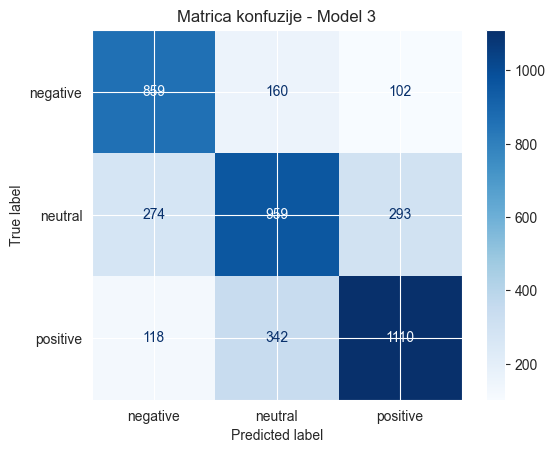

--- MODEL 3: IZVEŠTAJ O KLASIFIKACIJI
              precision    recall  f1-score   support

    negative       0.69      0.77      0.72      1121
     neutral       0.66      0.63      0.64      1526
    positive       0.74      0.71      0.72      1570

    accuracy                           0.69      4217
   macro avg       0.69      0.70      0.70      4217
weighted avg       0.69      0.69      0.69      4217



In [56]:
# 1. Fitovanje bazičnog modela
pipeline_model3.fit(X_train_c, y_train_c)
# 2. Predviđanje i rezultati
y_pred_3 = pipeline_model3.predict(X_test_c)

#kreiranje matrice konfuzije i classification report-a
cm = confusion_matrix(y_test_c, y_pred_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues')
plt.title('Matrica konfuzije - Model 3')
plt.show()

# 3. Klasifikacioni izveštaj
print("--- MODEL 3: IZVEŠTAJ O KLASIFIKACIJI")
print(classification_report(y_test_c, y_pred_3,target_names=le.classes_))

In [57]:
#Inicijalni Model 3 je odmah postao naš najbolji model sa tačnošću od 69%. Glavni razlog za ovaj skok je to što smo napravili hibrid, spajajući tekst tvita (kolona Clean_Tweet_Final) sa popularnošću tvita (Number of Likes).  logistička regresija radi tako što uzima sve te naše podatke, dodeljuje im određenu važnost (težine) i kroz tzv. sigmoidnu funkciju ih pretvara u verovatnoću — npr. model izračuna da postoji 85% šanse da je tvit negativan. Uvođenjem broja lajkova, dali smo modelu dodatnu informaciju' kojia mu pomaže da lakše donese odluku tamo gde same reči nisu dovoljne."
#izvor o logističkoj regresiji: https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/

In [58]:
# Definisanje proširene mreže parametara
param_grid_m3 = {
    'preprocessor__tfidf__ngram_range': [(1, 1), (1, 2)], #Testiramo da li parovi reči pomažu više u kombinaciji sa dužinom tvita.
    'clf__C': [0.1, 1, 10, 100],
}

grid_m3 = GridSearchCV(pipeline_model3, param_grid_m3, cv=5, scoring='f1_weighted', n_jobs=-1)

print("Optimizujem Model 3")
grid_m3.fit(X_train_c, y_train_c)

# Finalni rezultati nakon optimizacije
best_model3 = grid_m3.best_estimator_
y_pred_m3_opt = best_model3.predict(X_test_c)

print(f"\nNajbolji parametri: {grid_m3.best_params_}")
print("\n--- MODEL 3: IZVEŠTAJ OPTIMIZOVANOG MODELA ---")
print(classification_report(y_test_c, y_pred_m3_opt,target_names=le.classes_))

Optimizujem Model 3

Najbolji parametri: {'clf__C': 1, 'preprocessor__tfidf__ngram_range': (1, 1)}

--- MODEL 3: IZVEŠTAJ OPTIMIZOVANOG MODELA ---
              precision    recall  f1-score   support

    negative       0.70      0.75      0.73      1121
     neutral       0.64      0.65      0.65      1526
    positive       0.75      0.70      0.73      1570

    accuracy                           0.70      4217
   macro avg       0.70      0.70      0.70      4217
weighted avg       0.70      0.70      0.70      4217



In [59]:
#Nakon sprovedene optimizacije hiperparametara pomoću GridSearch-a, Model 3 je dostigao tačnost od 70%, što je blagi skok u odnosu na prvobitnih 70%.
#Iako smo testirali parove reči, ispostavilo se da su pojedinačne reči  u kombinaciji sa brojem lajkova sasvim dovoljne za najbolji rezultat.
#Za razliku od Random Forest-a, ovaj model kroz verovatnoće koristi dodatne informacije (u našem modelu dali smo mu kao dodatnu informaciju broj lajkova po tvitu), a pošto imamo tri kategorije sentimenata, koristili smo multinomsku (multinomial) varijantu logističke regresije koja se pokazala kao najuspešnije rešenje.
#

In [60]:
#kao četvrti i finalni model, odlučio sam se za XGBoost.
#Glavna razlika u odnosu na Random Forest je to što XGBoost koristi Boosting tehniku. To znači da on ne gradi stabla odjednom, već jedno po jedno, gde svako novo stablo uči na greškama onog prethodnog kako bi smanjilo ukupnu grešku modela. Koristimo istu hibridnu strukturu (TF-IDF + broj lajkova) kako bismo videli da li ovaj napredni algoritam može da nadmaši jednostavnije modele
#izvor: https://www.geeksforgeeks.org/machine-learning/xgboost-parameters/

from xgboost import XGBClassifier

# Definisanje XGBoost modela unutar Pipeline-a
# Koristimo isti preprocessor kao za Model 3 (TF-IDF + Scaling)
pipeline_model4 = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        objective='multi:softprob',
        random_state=42
    ))
])


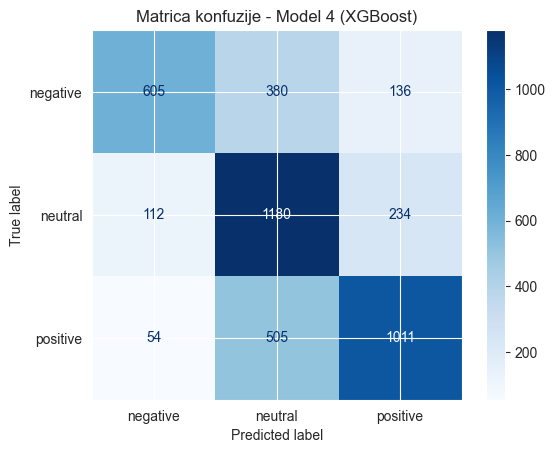


--- MODEL 4:IZVEŠTAJ ---
              precision    recall  f1-score   support

    negative       0.78      0.54      0.64      1121
     neutral       0.57      0.77      0.66      1526
    positive       0.73      0.64      0.69      1570

    accuracy                           0.66      4217
   macro avg       0.70      0.65      0.66      4217
weighted avg       0.69      0.66      0.66      4217



In [61]:
# Treniranje modela
pipeline_model4.fit(X_train_c, y_train_c)
# 3. Predviđanje
y_pred_m4 = pipeline_model4.predict(X_test_c)

# Matrica konfuzije
cm4 = confusion_matrix(y_test_c, y_pred_m4)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=le.classes_)
disp4.plot(cmap='Blues')
plt.title('Matrica konfuzije - Model 4 (XGBoost)')
plt.show()

print("\n--- MODEL 4:IZVEŠTAJ ---")
print(classification_report(y_test_c, y_pred_m4, target_names=le.classes_))

In [66]:
#Inicijalni XGBoost model je pokazao solidnu tačnost od 66%. Primetili smo da je model bio veoma dobar u prepoznavanju neutralnih tvitova (recall 0.77), ali je imao malo poteškoća sa negativnom klasom (recall 0.54)

In [63]:
#Definisanjed hiperparametara za optimizaciju performansi
#izvor: https://www.geeksforgeeks.org/machine-learning/xgboost-parameters/
param_grid_xgb = {
    'clf__n_estimators': [200, 300],    # Povećavamo broj stabala da nadoknadimo sporije učenje
    'clf__learning_rate': [0.1],        # Standardna vrednost (niže vrednosti stvaraju roubsnije modele, više vrednosti ubrzavaju učenje al veći je rizik od overfitinga)
    'clf__max_depth': [5, 6],           # Dubina stabla
    'clf__subsample': [0.8, 1.0],       # koristim od 80 do 100% podataka
    'clf__gamma': [0, 0.1]               #Minimalno smanjenje gubitka (poboljšanje) koje je potrebno da bi se napravilo novo grananje u stablu.
}

grid_xgb = GridSearchCV(pipeline_model4, param_grid_xgb, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_xgb.fit(X_train_c, y_train_c)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_opt = best_xgb.predict(X_test_c)

print(f"\nNajbolji parametri: {grid_xgb.best_params_}")
print("\n--- MODEL 4: OPTIMIZOVANI XGBOOST IZVEŠTAJ ---")
print(classification_report(y_test_c, y_pred_xgb_opt, target_names=le.classes_))


Najbolji parametri: {'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 300, 'clf__subsample': 0.8}

--- MODEL 4: OPTIMIZOVANI XGBOOST IZVEŠTAJ ---
              precision    recall  f1-score   support

    negative       0.78      0.57      0.66      1121
     neutral       0.58      0.75      0.66      1526
    positive       0.73      0.66      0.69      1570

    accuracy                           0.67      4217
   macro avg       0.70      0.66      0.67      4217
weighted avg       0.69      0.67      0.67      4217



In [64]:
#Iako je XGBoost izuzetno moćan, za ovaj konkretan dataset i broj tvitova (jer se koristi za datasetove sa velikim brojem podataka), Logistička regresija je pokazala najbolje rezultate sa 71%. Ovo potvrđuje pravilo da u mašinskom učenju kompleksiniji algoritmi nisu uvek garancija boljeg rezultata, naročito kada radimo sa haotičnim podacima kao što su reakcije navijača na Twitteru.

In [67]:
#Za kraj, izvrsicemo poredjenje svih nasil modela tj njihovih najboljih verzija, u mom slučaju su bolje verzije nakon optimizacije
from sklearn import metrics
def get_model_metrics(y_true, y_pred, model_name):
    report = metrics.classification_report(y_true, y_pred, output_dict=True)
    b_acc = metrics.balanced_accuracy_score(y_true, y_pred)

    macro_avg = report['macro avg']
    weighted_avg = report['weighted avg']

    results = {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Macro F1-Score': macro_avg['f1-score'],
        'Macro Precision': macro_avg['precision'],
        'Macro Recall': macro_avg['recall'],
        'Balanced Accuracy': b_acc,
        'Weighted F1-Score': weighted_avg['f1-score']
    }
    return results

# Rečnik sa tvojim optimizovanim predikcijama
comparison_data = {
    'Model 1 (MNB)': (y_test, y_pred_m1_opt),
    'Model 2 (RF)': (y_test, y_pred_rf_opt),
    'Model 3 (Logistic Hybrid)': (y_test_c, y_pred_m3_opt),
    'Model 4 (XGBoost Hybrid)': (y_test_c, y_pred_xgb_opt)
}
all_results = []
for name, (y_true, y_pred) in comparison_data.items():
    res = get_model_metrics(y_true, y_pred, name)
    all_results.append(res)

all_results_df = pd.DataFrame(all_results)
all_results_df.set_index("Model", inplace=True)

# Prikaz tabele sortirane od najboljeg ka najgorem
display(all_results_df.sort_values(by='Accuracy', ascending=False))

"""
INTERPRETACIJA I DISKUSIJA
Nakon testiranja četiri različita modela za klasifikaciju sentimenta Twitter objava sa Svetskog prvenstva, dobili smo finalni poredak. Najuspešniji se pokazao Model 3 (Logistic Hybrid) sa preciznošću od skoro 70% (0.697), dok je Random Forest (Model 2) ostvario najslabiji rezultat od 61%.

Pobeda hirbidnog modela sa korišćenjem Logistic Regression algoritma nam govori da sam sadržaj tvita nije jedini bitan faktor. Kombinovanjem TF-IDF vektora sa brojem lajkova, logistička regresija je uspela da bolje prepozna kojoj klasi sentimenata pripada određeni tvit nego kada smo koristili samo reči.
I ostali modeli su se pokazali kao dobri, gde nam svaki model ima bar preko 60% uspešnosti predvđanja, što je na ovom velikom datasetu zadovoljavajuće.

U nekom sledećem koraku, rezultati bi mogli biti još bolji uz:
Analizu emodžija: S obzirom na to da navijači emocije često izražavaju isključivo kroz smajlije, njihovo uključivanje u obradu teksta bi sigurno pomoglo u još boljim rezultatima.
Analiza celog prvenstva, a ne samo jednog segmenta (u ovom datasetu su samo tvitovi sa prvog dana prvenstva).
"""

,Accuracy,Macro F1-Score,Macro Precision,Macro Recall,Balanced Accuracy,Weighted F1-Score
Model,,,,,,
Model 3 (Logistic Hybrid),0.697178,0.699679,0.698407,0.701880,0.701880,0.697311
Model 1 (MNB),0.688404,0.690158,0.692154,0.689193,0.689193,0.687669
Model 4 (XGBoost Hybrid),0.670619,0.670336,0.697315,0.662230,0.662230,0.671411
Model 2 (RF),0.613469,0.612194,0.617241,0.609616,0.609616,0.612785


'\nINTERPRETACIJA I DISKUSIJA\nNakon testiranja četiri različita modela za klasifikaciju sentimenta Twitter objava sa Svetskog prvenstva, dobili smo finalni poredak. Najuspešniji se pokazao Model 3 (Logistic Hybrid) sa preciznošću od skoro 70% (0.697), dok je Random Forest (Model 2) ostvario najslabiji rezultat od 61%.\n\nPobeda hirbidnog modela sa korišćenjem Logistic Regression algoritma nam govori da sam sadržaj tvita nije jedini bitan faktor. Kombinovanjem TF-IDF vektora sa brojem lajkova, logistička regresija je uspela da bolje prepozna kojoj klasi sentimenata pripada određeni tvit nego kada smo koristili samo reči.\nI ostali modeli su se pokazali kao dobri, gde nam svaki model ima bar preko 60% uspešnosti predvđanja, što je na ovom velikom datasetu zadovoljavajuće.\n\nU nekom sledećem koraku, rezultati bi mogli biti još bolji uz:\nAnalizu emodžija: S obzirom na to da navijači emocije često izražavaju isključivo kroz smajlije, njihovo uključivanje u obradu teksta bi sigurno pomogl